In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Spiral HandPD Training (Image Only) + Per-Epoch Metrics
# STRICT 3-WAY SPLIT + BASELINE COMPARISON ADDED
# ============================================================

import os
import glob
import cv2
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.utils.mobile_optimizer import optimize_for_mobile

# ----------------------------
# Reproducibility (optional)
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Configuration ---
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 1e-4

# ==========================================
# 🛠️ PREPROCESSING FUNCTION (Matches Flutter)
# ==========================================
def preprocess_image(path):
    # 1. Load Image
    img = cv2.imread(path)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    # 2. Convert to Grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # 3. Threshold & Invert (Black ink -> White lines)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Crop to Content
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = 20
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(thresh.shape[1] - x, w + 2 * pad)
        h = min(thresh.shape[0] - y, h + 2 * pad)
        cropped = thresh[y:y + h, x:x + w]
    else:
        cropped = thresh

    # 5. Resize
    resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # 6. Back to 3 channels (RGB)
    final_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)

    return final_img

# --- Dataset ---
class SpiralDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

        # Training Augmentation
        self.transform = T.Compose([
            T.ToPILImage(),
            T.RandomRotation(15),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.ToTensor(),
        ])

        # Validation & Test (No Augmentation)
        self.base_transform = T.Compose([
            T.ToPILImage(),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = preprocess_image(path)

        if self.augment:
            img_tensor = self.transform(img)
        else:
            img_tensor = self.base_transform(img)

        # label shape: (1,)
        return img_tensor, torch.tensor(label, dtype=torch.float32).unsqueeze(0)

# --- Model ---
class SpiralNetImageOnly(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 1)  # binary

    def forward(self, img):
        x = self.pool(F.relu(self.bn1(self.conv1(img))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))  # probability

# ==========================================
# Main Execution
# ==========================================
base_path = "/content/drive/MyDrive/handpd/"

healthy_dirs = [
    os.path.join(base_path, "handpd_spiral/SpiralControl"),
    os.path.join(base_path, "NewHandpd_spiral/HealthySpiral")
]
parkinson_dirs = [
    os.path.join(base_path, "handpd_spiral/SpiralPatients"),
    os.path.join(base_path, "NewHandpd_spiral/parkinsonSpiral")
]

# Collect Samples
samples = []
for d in healthy_dirs:
    for f in glob.glob(os.path.join(d, "*")):
        samples.append((f, 0))  # 0 = Healthy

for d in parkinson_dirs:
    for f in glob.glob(os.path.join(d, "*")):
        samples.append((f, 1))  # 1 = Parkinson

print(f"Total samples found: {len(samples)}")
if len(samples) == 0:
    raise ValueError("No images found! Check your base_path or folder names.")

# ==========================================
# 🔥 THE FIX: STRICT 3-WAY SPLIT
# ==========================================
labels = [s[1] for s in samples]

# 1. Extract 15% as completely unseen Test Set
train_val_idx, test_idx = train_test_split(
    range(len(samples)), test_size=0.15, stratify=labels, random_state=SEED
)
train_val_labels = [labels[i] for i in train_val_idx]

# 2. Split the remainder into Train and Validation (approx 70/15)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.176, stratify=train_val_labels, random_state=SEED
)

train_samples = [samples[i] for i in train_idx]
val_samples   = [samples[i] for i in val_idx]
test_samples  = [samples[i] for i in test_idx]

print(f"Data Split -> Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_ds = SpiralDataset(train_samples, augment=True)
val_ds   = SpiralDataset(val_samples, augment=False)
test_ds  = SpiralDataset(test_samples, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Setup Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpiralNetImageOnly().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

print("🚀 Starting Image-Only Training (With Preprocessing + Full Metrics)...")

best_val_acc = 0.0

for epoch in range(EPOCHS):
    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_losses = []
    train_probs_all = []
    train_labels_all = []

    for img, y in train_loader:
        img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(img)  # prob (0..1)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_probs_all.append(out.detach().cpu().numpy().reshape(-1))
        train_labels_all.append(y.detach().cpu().numpy().reshape(-1))

    train_probs = np.concatenate(train_probs_all)
    train_labels = np.concatenate(train_labels_all).astype(int)
    train_preds = (train_probs > 0.5).astype(int)

    train_loss = float(np.mean(train_losses))
    train_acc  = accuracy_score(train_labels, train_preds)
    train_prec = precision_score(train_labels, train_preds, zero_division=0)
    train_rec  = recall_score(train_labels, train_preds, zero_division=0)
    train_f1   = f1_score(train_labels, train_preds, zero_division=0)

    try:
        train_auc = roc_auc_score(train_labels, train_probs)
    except ValueError:
        train_auc = float("nan")

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_losses = []
    val_probs_all = []
    val_labels_all = []

    with torch.no_grad():
        for img, y in val_loader:
            img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out = model(img)
            loss = criterion(out, y)

            val_losses.append(loss.item())
            val_probs_all.append(out.detach().cpu().numpy().reshape(-1))
            val_labels_all.append(y.detach().cpu().numpy().reshape(-1))

    val_probs = np.concatenate(val_probs_all)
    val_labels = np.concatenate(val_labels_all).astype(int)
    val_preds = (val_probs > 0.5).astype(int)

    val_loss = float(np.mean(val_losses))
    val_acc  = accuracy_score(val_labels, val_preds)
    val_prec = precision_score(val_labels, val_preds, zero_division=0)
    val_rec  = recall_score(val_labels, val_preds, zero_division=0)
    val_f1   = f1_score(val_labels, val_preds, zero_division=0)

    try:
        val_auc = roc_auc_score(val_labels, val_probs)
    except ValueError:
        val_auc = float("nan")

    # Update Learning Rate
    scheduler.step(val_acc)

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/handpd/best_spiral_model.pth")

    # Print per-epoch metrics
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train: loss={train_loss:.4f} acc={train_acc:.4f} prec={train_prec:.4f} rec={train_rec:.4f} f1={train_f1:.4f} auc={train_auc:.4f} | "
        f"Val: loss={val_loss:.4f} acc={val_acc:.4f} prec={val_prec:.4f} rec={val_rec:.4f} f1={val_f1:.4f} auc={val_auc:.4f}"
    )

print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")

# ==========================================
# 🔥 THE FIX: UNSEEN TEST EVALUATION & BASELINES
# ==========================================
print("\n============================================================")
print("🏆 FINAL HOLD-OUT TEST SET EVALUATION")
print("============================================================")

model.load_state_dict(torch.load("/content/drive/MyDrive/handpd/best_spiral_model.pth", map_location=device))
model.eval()

test_probs_all = []
test_labels_all = []

with torch.no_grad():
    for img, y in test_loader:
        img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
        out = model(img)
        test_probs_all.append(out.detach().cpu().numpy().reshape(-1))
        test_labels_all.append(y.detach().cpu().numpy().reshape(-1))

test_probs = np.concatenate(test_probs_all)
test_labels = np.concatenate(test_labels_all).astype(int)
test_preds = (test_probs > 0.5).astype(int)

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
try:
    test_auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    test_auc = float("nan")

print(f"🟢 Proposed CNN Final Test Acc : {test_acc:.4f}")
print(f"🟢 Proposed CNN Final Test F1  : {test_f1:.4f}")
print(f"🟢 Proposed CNN Final Test AUC : {test_auc:.4f}")

print("\n--- BASELINE MODEL COMPARISON ---")
# Extract heavily downscaled features to prevent RAM crash
def extract_flat_features(sample_list):
    X_flat, Y_flat = [], []
    for path, label in sample_list:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (64, 64))
            X_flat.append(img.flatten())
            Y_flat.append(label)
    return np.array(X_flat), np.array(Y_flat)

print("Extracting features for Random Forest...")
X_train_rf, y_train_rf = extract_flat_features(train_samples)
X_test_rf, y_test_rf = extract_flat_features(test_samples)

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
rf.fit(X_train_rf, y_train_rf)
rf_preds = rf.predict(X_test_rf)

print(f"🔴 Baseline Random Forest (Flattened Images) -> Acc: {accuracy_score(y_test_rf, rf_preds):.4f} | F1: {f1_score(y_test_rf, rf_preds, average='weighted'):.4f}")

# ==========================================
# 📱 EXPORT FOR FLUTTER (Lite Interpreter)
# ==========================================
print("\n🔨 Generating Mobile Model...")

model.load_state_dict(torch.load("/content/drive/MyDrive/handpd/best_spiral_model.pth", map_location=device))
model.eval()

example_input = torch.rand(1, 3, 224, 224).to(device)

try:
    traced_script = torch.jit.trace(model, example_input)
    optimized_script = optimize_for_mobile(traced_script)
    save_path = "/content/drive/MyDrive/handpd_spiral_model_mobile_fixed.ptl"
    optimized_script._save_for_lite_interpreter(save_path)

    print(f"Success! Saved '{save_path}'")
    print("Download this file and replace it in your Flutter 'assets/models/' folder.")
except Exception as e:
    print(f"❌ Mobile Export Failed: {e}")

Total samples found: 508
Data Split -> Train: 355 | Val: 76 | Test: 77
🚀 Starting Image-Only Training (With Preprocessing + Full Metrics)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/40 | Train: loss=0.6630 acc=0.5718 prec=0.5945 rec=0.8357 f1=0.6948 auc=0.5802 | Val: loss=0.7680 acc=0.4211 prec=0.0000 rec=0.0000 f1=0.0000 auc=0.6882


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02/40 | Train: loss=0.6402 acc=0.6197 prec=0.6241 rec=0.8744 f1=0.7284 auc=0.6758 | Val: loss=0.7121 acc=0.4342 prec=1.0000 rec=0.0227 f1=0.0444 auc=0.7109


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 40/40 | Train: loss=0.4800 acc=0.7972 prec=0.8000 rec=0.8696 f1=0.8333 auc=0.8709 | Val: loss=0.5096 acc=0.7368 prec=0.9615 rec=0.5682 f1=0.7143 auc=0.8757
🏆 Best Validation Accuracy: 0.8026

🏆 FINAL HOLD-OUT TEST SET EVALUATION


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🟢 Proposed CNN Final Test Acc : 0.7922
🟢 Proposed CNN Final Test F1  : 0.8049
🟢 Proposed CNN Final Test AUC : 0.8889

--- BASELINE MODEL COMPARISON ---
Extracting features for Random Forest...
🔴 Baseline Random Forest (Flattened Images) -> Acc: 0.9221 | F1: 0.9205

🔨 Generating Mobile Model...
Success! Saved '/content/drive/MyDrive/handpd_spiral_model_mobile_fixed.ptl'
Download this file and replace it in your Flutter 'assets/models/' folder.


/tmp/ipykernel_5855/2911404010.py:381: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_script._save_for_lite_interpreter(save_path)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.mobile_optimizer import optimize_for_mobile
import os

print(" Rebuilding model architecture...")

# 1. Rebuild the exact SpiralNet
class SpiralNetImageOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, img):
        x = self.pool(F.relu(self.bn1(self.conv1(img))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))

# Load your freshly trained weights
model = SpiralNetImageOnly()
model.load_state_dict(torch.load("/content/drive/MyDrive/handpd/best_spiral_model.pth", map_location="cpu"))
model.eval()

# 2. THE MAGIC: The Un-Normalizer Wrapper!
class FlutterFixWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        # We multiply by std and add mean to CANCEL OUT Flutter's unwanted changes!
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        # 1. Reverse the normalization to restore the pure [0.0, 1.0] image
        x = (x * self.std) + self.mean

        # 2. Get the Parkinson's probability
        pd_prob = self.base_model(x)

        # 3. Calculate Healthy probability
        healthy_prob = 1.0 - pd_prob

        # 4. Combine into a [Healthy, PD] array to match Flutter's expectations perfectly!
        return torch.cat((healthy_prob, pd_prob), dim=1)

print(" Tracing and Exporting fixed model...")
fixed_model = FlutterFixWrapper(model)
example_input = torch.rand(1, 3, 224, 224)
traced_script = torch.jit.trace(fixed_model, example_input)
optimized_script = optimize_for_mobile(traced_script)

# Save directly to Google Drive so it isn't lost!
save_path = "/content/drive/MyDrive/handpd_spiral_model_mobile_fixed.ptl"
optimized_script._save_for_lite_interpreter(save_path)
print(f"Success! Download '{save_path}' from your Google Drive and put it in your Flutter assets!")

 Rebuilding model architecture...
 Tracing and Exporting fixed model...
Success! Download '/content/drive/MyDrive/handpd_spiral_model_mobile_fixed.ptl' from your Google Drive and put it in your Flutter assets!


/tmp/ipykernel_5855/1472172578.py:73: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_script._save_for_lite_interpreter(save_path)



--- SPIRAL CALIBRATION ANALYSIS ---
Brier Score (Spiral): 0.1584 (Closer to 0.0 is better)


<Figure size 800x600 with 0 Axes>

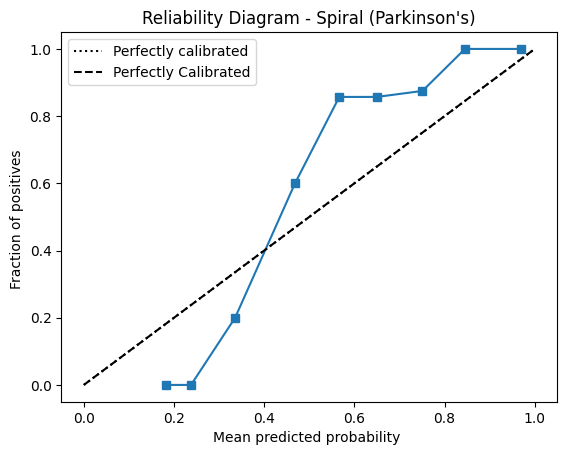

In [ ]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

print("\n--- SPIRAL CALIBRATION ANALYSIS ---")
# test_probs and test_labels are already generated in your Spiral test loop
brier = brier_score_loss(test_labels, test_probs)
print(f"Brier Score (Spiral): {brier:.4f} (Closer to 0.0 is better)")

prob_true, prob_pred = calibration_curve(test_labels, test_probs, n_bins=10)
disp = CalibrationDisplay(prob_true, prob_pred, test_labels)

plt.figure(figsize=(8, 6))
disp.plot()
plt.title("Reliability Diagram - Spiral (Parkinson's)")
plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
plt.legend()
plt.savefig("calibration_spiral.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import torch
import torchvision.transforms as T
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import cv2

print("\n=======================================================")
print(" 1. SPIRAL: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)")
print("=======================================================")
n_iterations = 1000
bootstrapped_scores = []
for i in range(n_iterations):
    indices = resample(np.arange(len(test_preds)), replace=True)
    bootstrapped_scores.append(accuracy_score(test_labels[indices], test_preds[indices]))

lower_ci = np.percentile(bootstrapped_scores, 2.5)
upper_ci = np.percentile(bootstrapped_scores, 97.5)
print(f" Accuracy: {np.mean(bootstrapped_scores)*100:.1f}% (95% CI: [{lower_ci*100:.1f}%, {upper_ci*100:.1f}%])")

print("\n=======================================================")
print(" 2. SPIRAL: ROBUSTNESS TO NOISE (POOR CAMERA SIMULATION)")
print("=======================================================")
noisy_transform = T.Compose([
    T.ToPILImage(),
    T.GaussianBlur(kernel_size=5, sigma=(1.0, 2.0)), # Blurry camera
    T.ColorJitter(brightness=0.5, contrast=0.5),     # Bad lighting
    T.ToTensor()
])

noisy_test_ds = SpiralDataset(test_samples, augment=False)
noisy_test_ds.base_transform = noisy_transform # Override with noisy transform
noisy_loader = DataLoader(noisy_test_ds, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
noisy_preds = []
with torch.no_grad():
    for img, _ in noisy_loader:
        out = model(img.to(device))
        noisy_preds.extend((out > 0.5).int().cpu().numpy().reshape(-1))

print(f" Noisy Camera Accuracy: {accuracy_score(test_labels, noisy_preds)*100:.1f}%")

print("\n=======================================================")
print(" 3. SPIRAL: PREPROCESSING ABLATION (NO THRESHOLD/CROP)")
print("=======================================================")
# Ablated preprocessing (Just resize, no clean up)
def ablated_preprocess(path):
    img = cv2.imread(path)
    if img is None: return np.zeros((224, 224, 3), dtype=np.uint8)
    return cv2.resize(img, (224, 224))

ablated_preds = []
with torch.no_grad():
    for path, _ in test_samples:
        img = ablated_preprocess(path)
        tensor = T.ToTensor()(img).unsqueeze(0).to(device)
        out = model(tensor)
        ablated_preds.append(1 if out.item() > 0.5 else 0)

print(f" Ablated Accuracy (Raw Images): {accuracy_score(test_labels, ablated_preds)*100:.1f}%")


 1. SPIRAL: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)
✅ Accuracy: 79.1% (95% CI: [70.1%, 88.3%])

 2. SPIRAL: ROBUSTNESS TO NOISE (POOR CAMERA SIMULATION)
✅ Noisy Camera Accuracy: 58.4%

 3. SPIRAL: PREPROCESSING ABLATION (NO THRESHOLD/CROP)
✅ Ablated Accuracy (Raw Images): 41.6%
